---
title: "Wakao–Funazkri: the correlation that came from putting axial dispersion back in"
description: "Sh = 2 + 1.1 Sc^(1/3) Re^0.6 is what the packed-bed mass-transfer data say once the axial dispersion coefficient is no longer assumed to be zero. This page rebuilds the re-analysis that produced it."
categories: [sec:A, struct:S3, tier:T1, data:tier4, phase:gas-solid]
date: 2026-07-30
---

# Wakao–Funazkri: the correlation that came from putting axial dispersion back in

**Catalog ID:** `A3.4` · **Structures:** `S3` (steady 1-D convection–diffusion–reaction) · **Tier:** T1

Almost every packed-bed model in use contains

$$\mathrm{Sh} = 2 + 1.1\,\mathrm{Sc}^{1/3}\,\mathrm{Re}^{0.6}$$

and almost nobody remembers what it replaced. Wakao and Funazkri did not measure
anything. They took thirty-five years of published mass-transfer data, noticed
that the people who produced it had solved the wrong equation, and solved the
right one.

**The wrong equation was plug flow.** A packed-bed transfer experiment measures
one number — how much of the transferring species leaves the bed. Turning that
into a coefficient needs a model of the bed, and if the model has no axial
dispersion in it then all of the observed depletion is charged to the film. At
low flow rates that is a large error, and it always runs the same way: it makes
the coefficient too small.

This page rebuilds that re-analysis. The bed model is a 1-D convection–
diffusion–reaction problem with Danckwerts boundary conditions, which is
something pymrm actually solves; the paper's Eq. 7 is its closed-form solution
and becomes a validation target rather than an input.

## Background

By 1978 the *j*-factor correlations for particle-to-fluid mass transfer had a
well-known and embarrassing property: extrapolated to low Reynolds number they
predict $\mathrm{Sh} \to 0$. A sphere sitting motionless in a stagnant fluid has
$\mathrm{Sh} = 2$. The correlations said the coefficient falls through that
floor and keeps going.

Everyone knew this. The usual explanation was that packed beds are not single
spheres. Wakao and Funazkri's answer is different and much sharper: **the low-Re
numbers are wrong, and they are wrong because of how they were extracted from
the raw measurements, not because of anything that happens in the bed.**

The argument runs like this. In a steady evaporation, sublimation or dissolution
experiment you measure the inlet and outlet concentrations. The mass balance
along the bed is

$$U \frac{\mathrm{d}C}{\mathrm{d}x} - D_{ax}\frac{\mathrm{d}^2 C}{\mathrm{d}x^2}
+ \frac{a}{\varepsilon_b}k_f\,(C - C_s) = 0 ,$$

which has **two** transport parameters, $D_{ax}$ and $k_f$, and only one
measurement. To get $k_f$ you must supply $D_{ax}$ from somewhere. Most of the
literature supplied $D_{ax} = 0$. Petrovic and Thodos, more carefully, supplied
the packed-bed asymptote $\mathrm{Pe} = d_p U / D_{ax} = 2$.

What Wakao et al. had just shown, in the companion paper, is that a *mass
transferring* species does not have the same axial dispersion coefficient as an
inert tracer, and that the stagnant contribution is far larger than the 0.6–0.8
everybody was using. Put that number in and the low-Re coefficients move — a
lot, for gases; not at all, for liquids.

The result is a correlation with the stagnant-sphere limit built in, which is
the one still in use.

## The published model

**The dispersion coefficient** (their Eqs. 1–3; $D_v$ is the molecular
diffusivity, $E^0$ the stagnant contribution):

$$D_{ax} = \frac{E^0}{\varepsilon_b} + \tfrac12 d_p U
\qquad\Longrightarrow\qquad
\frac{\varepsilon_b D_{ax}}{D_v} = \frac{E^0}{D_v} + \tfrac12\,\mathrm{Sc}\,\mathrm{Re}.$$

For a species being transferred *at the particle surface* — evaporation,
sublimation, dissolution, or a diffusion-controlled surface reaction — the
chart in the companion paper gives $E^0/D_v = 20$, so (Eq. 2)

$$\boxed{\ \frac{\varepsilon_b D_{ax}}{D_v} = 20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}\ }$$

whereas under **inert** conditions (Eq. 3) the stagnant term is only
$(0.6\text{–}0.8)\,\varepsilon_b$. That factor of about 30 between the two
stagnant terms is the entire paper.

**The bed model** (Eq. 4) with Danckwerts boundary conditions (Eq. 5):

$$U \frac{\mathrm{d}C}{\mathrm{d}x} - D_{ax}\frac{\mathrm{d}^2 C}{\mathrm{d}x^2}
+ \frac{a}{\varepsilon_b}k_f (C - C_s) = 0,\qquad
U(C-C_{in}) = D_{ax}\frac{\mathrm{d}C}{\mathrm{d}x}\Big|_{0},\qquad
\frac{\mathrm{d}C}{\mathrm{d}x}\Big|_{L} = 0 .$$

**Its closed-form solution** (Eq. 7) — the classical closed-vessel first-order
result:

$$\frac{C_s - C_{exit}}{C_s - C_{in}}
= \frac{4A\exp\!\left[\dfrac{UL}{2D_{ax}}\right]}
{(1+A)^2\exp\!\left[A\dfrac{UL}{2D_{ax}}\right]-(1-A)^2\exp\!\left[-A\dfrac{UL}{2D_{ax}}\right]},
\qquad A = \sqrt{1 + \frac{4\,a\,k_f D_{ax}}{\varepsilon_b U^2}} .$$

**Its plug-flow limit** (Eq. 8), which is what the original authors inverted:

$$\frac{C_s - C_{exit}}{C_s - C_{in}} = \exp\!\left[-\frac{\mathrm{Sh}'}{\mathrm{Sc}\,\mathrm{Re}}aL\right].$$

$\mathrm{Sh}'$ is the Sherwood number you get by assuming $D_{ax}=0$;
$\mathrm{Sh}$ is the one you get from Eq. 7 with $D_{ax}$ from Eq. 2. **The
paper is the map from $\mathrm{Sh}'$ to $\mathrm{Sh}$.**

**The three correlations this page compares:**

| | |
|---|---|
| Eq. 12, this paper | $\mathrm{Sh} = 2 + 1.1\,\mathrm{Sc}^{1/3}\mathrm{Re}^{0.6}$, $3 \lesssim \mathrm{Re} \le 10^4$ |
| Eq. 9, Ranz–Marshall, single spheres | $\mathrm{Sh} = 2 + 0.6\,\mathrm{Sc}^{1/3}\mathrm{Re}^{1/2}$ |
| Eq. 11, Petrovic–Thodos, what Eq. 12 replaced | $\varepsilon_b j_D = 0.357\,\mathrm{Re}^{-0.359}$, $3 < \mathrm{Re} < 900$ |

All Reynolds numbers are $\mathrm{Re} = d_p U \varepsilon_b/\nu$, i.e. built on
the **superficial** velocity, as the paper's notation list specifies
($U$ itself is interstitial).

## Parameters and assumptions

Everything on this page is dimensionless, which is deliberate: the paper's own
argument is, and reconstructing particle diameters and bed heights for
thirty-eight literature sources would be inventing data.

Three groups carry all of it. With $a = 6(1-\varepsilon_b)/d_p$ for spheres and
$L/d_p$ the number of particle layers:

$$N = \frac{a k_f L}{\varepsilon_b U} = \frac{6(1-\varepsilon_b)\,\mathrm{Sh}\,(L/d_p)}{\mathrm{Sc}\,\mathrm{Re}},
\qquad
\mathrm{Pe}_L = \frac{UL}{D_{ax}} = \frac{\mathrm{Sc}\,\mathrm{Re}}{20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}}\cdot\frac{L}{d_p},
\qquad
\theta = \frac{C_s - C_{exit}}{C_s - C_{in}} .$$

$N$ is the number of transfer units; $\mathrm{Pe}_L$ is the bed Péclet number.
Note that $\mathrm{Pe}_L/(L/d_p)$ — the *particle* Péclet number — tends to 2 as
$\mathrm{Sc}\,\mathrm{Re}\to\infty$, which is exactly the value Petrovic and
Thodos assumed everywhere.

**Assumptions taken from the paper.** All resistance in the fluid film, constant
surface concentration, steady state, spheres, all particles active, more than
two particle layers. Bed void fraction is taken as $\varepsilon_b = 0.40$;
$L/d_p$ is swept, because it is not reported per data set and the answer turns
out to depend on it only weakly.

**What the data collection excludes,** because it is part of the argument: all
non-steady measurements (pulse chromatography — too many parameters), liquid
data below $\mathrm{Re}=3$ (natural convection), Hurt's and Resnick's
naphthalene work (the vapour pressures in Table 3 disagree badly, and small
errors there are magnified), Hobson and Thodos' extraction runs, and Selke's ion
exchange.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A3.4-wakao-funazkri"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

Two files. The parameter table holds every constant read off the page images —
the paper is a 1978 Elsevier scan whose text layer drops decimal points, so
nothing here was transcribed mechanically.

The second file is **81 marker positions digitised from Figure 2**, the
gas-phase water-evaporation data *after* re-evaluation, at the Schmidt number
0.6 printed inside the figure. That is the figure where the correction bites, so
it is the one worth extracting.

**This extraction has not yet been reviewed by a maintainer, and the page is
staged rather than published because of it.** Read the sidecar before using the
file. What is known: the axis calibration is confirmed to within a line width by
three curves whose equations the paper prints (see Validation), and a visual
audit at 600 dpi rejected six of eighty-seven automatic candidates. What is not
known is how many markers the detector missed in the dense band above
$\mathrm{Re}=100$, where the glyphs overlap each other and the drawn curves; the
true count is probably nearer 110 than 81.

**Nothing on this page that matters depends on those 81 points.** The results
below are algebra and a solved boundary-value problem; Figure 2 enters only in
the last of the six checks.

In [3]:
obs = load_data("wakao-funazkri-1978-fig2.csv", page=PAGE)
par = load_data("wakao-funazkri-1978-parameters.csv", page=PAGE)
obs_meta = load_meta("wakao-funazkri-1978-fig2.csv", page=PAGE)
P = dict(zip(par.quantity, par.value))

SC_FIG2 = P["Sc_figure2"]
ALPHA, BETA = P["alpha_eq12"], P["beta_eq12"]
E0 = P["E0_over_Dv"]                    # 20, eq. (2)
E0_INERT = (P["E0_over_Dv_inert_lo"], P["E0_over_Dv_inert_hi"])
SLOPE = P["dispersion_slope"]           # 0.5
PE_PT = P["Pe_petrovic"]                # 2
EPS_B = P["eps_b_figure2"]              # 0.40

Re_obs, Sh_obs = obs.Re.values, obs.Sh.values
print(f"{len(obs)} digitised Figure 2 markers, "
      f"Re {Re_obs.min():.1f} to {Re_obs.max():.0f}, "
      f"Sh {Sh_obs.min():.1f} to {Sh_obs.max():.0f}")
print(f"eq. (12):  Sh = 2 + {ALPHA} Sc^(1/3) Re^{BETA}")
print(f"eq. (2):   eps_b D_ax / D_v = {E0:.0f} + {SLOPE} Sc Re")
print(f"eq. (3):   eps_b D_ax*/ D_v = ({E0_INERT[0]}-{E0_INERT[1]}) eps_b + {SLOPE} Sc Re   [inert]")
print(f"\n{cite_data(obs_meta)}")
print(f"review status: {obs_meta['review']['status']}")

81 digitised Figure 2 markers, Re 4.1 to 831, Sh 3.6 to 82
eq. (12):  Sh = 2 + 1.1 Sc^(1/3) Re^0.6
eq. (2):   eps_b D_ax / D_v = 20 + 0.5 Sc Re
eq. (3):   eps_b D_ax*/ D_v = (0.6-0.8) eps_b + 0.5 Sc Re   [inert]

Wakao, N.; Funazkri, T. (1978) — Chemical Engineering Science 33(10) 1375-1384 — doi:10.1016/0009-2509(78)85120-3 — digitised from Figure 2, journal page 1382 (PDF page 8)
review status: pending


## PyMRM implementation

Two pieces. The first is the bed model, Eq. 4, discretised with pymrm's
operators. The second is the inversion that the paper performs by hand: given a
measured outlet, and a choice of dispersion coefficient, what $\mathrm{Sh}$
reproduces it.

**The boundary condition is where the physics is, so write it out.** pymrm's
`bc` uses the **outward** normal, $a\,\partial c/\partial n + b\,c = d$. On the
dimensionless bed $z = x/L$, $\theta = (C-C_s)/(C_{in}-C_s)$, the Danckwerts
inlet $U(C - C_{in}) = D_{ax}\,\mathrm{d}C/\mathrm{d}x$ becomes
$-\mathrm{Pe}_L^{-1}\theta' + \theta = 1$ at $z=0$, and at $z=0$ the outward
normal points in $-z$, so $\partial\theta/\partial n = -\theta'$ and the
coefficients are $a = 1/\mathrm{Pe}_L$, $b = 1$, $d = 1$. The outlet is plain
$\theta'(1)=0$, i.e. $a=1, b=0, d=0$ — which at the *right* boundary means
$+\theta' = 0$, the same equation, because a zero gradient does not care which
way the normal points. Anywhere else that sign flip matters.

The operators are assembled once per $(N, \mathrm{Pe}_L)$ and the problem is
linear, so there is no Newton loop — one sparse solve.

In [4]:
from pymrm import (construct_grad, construct_div, construct_convflux_upwind,
                   construct_boundary_value_matrices)


def theta_pymrm(N, Pe_L, n=1600, profile=False):
    """Outlet theta from eq. (4) with Danckwerts BCs, solved with pymrm.

    Dimensionless: theta' - Pe_L^-1 theta'' + N theta = 0 on 0 < z < 1.
    """
    shape = (n,)
    z_f = np.linspace(0.0, 1.0, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    # a dc/dn + b c = d, OUTWARD normal.
    #   z=0 (n = -z):  -Pe_L^-1 theta' + theta = 1   <- Danckwerts inlet, eq. (5)
    #   z=1 (n = +z):            theta'        = 0   <- Danckwerts outlet
    bc = ({"a": 1.0 / Pe_L, "b": 1.0, "d": 1.0},
          {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=1.0)
    grad, grad_bc = construct_grad(shape, z_f, z_c, bc)
    div = construct_div(shape, z_f, nu=0)          # nu=0: Cartesian slab
    jac = div @ (conv - grad / Pe_L) + N * eye_array(n, format="csr")
    rhs = -np.asarray((div @ (conv_bc - grad_bc / Pe_L)).todense()).ravel()
    th = spsolve(jac.tocsc(), rhs)
    Bv, Bg = construct_boundary_value_matrices(shape, z_f, z_c, bc=bc[1], bound_id=1)
    th_out = float((Bv @ th).ravel()[0] + np.asarray(Bg.todense()).ravel()[0])
    return (th, z_c, th_out) if profile else th_out


def theta_eq7(N, Pe_L):
    """Eq. (7): the closed-form outlet. Written with exp(A*Pe_L/2) factored out
    so it stays finite when the bed is long."""
    A = np.sqrt(1.0 + 4.0 * N / Pe_L)
    B = 0.5 * Pe_L
    return 4 * A * np.exp(B - A * B) / ((1 + A) ** 2 - (1 - A) ** 2 * np.exp(-2 * A * B))


def theta_eq8(N):
    """Eq. (8): the plug-flow limit, D_ax -> 0."""
    return np.exp(-N)


print("eq. (4) solved with pymrm vs eq. (7), the analytical outlet")
print(f"   {'N':>6}{'Pe_L':>7}{'eq. 7':>13}{'pymrm n=1600':>15}{'rel. err':>12}")
for N, Pe in ((1.0, 40.0), (5.0, 10.0), (0.5, 4.0), (20.0, 2.0)):
    ex, num = theta_eq7(N, Pe), theta_pymrm(N, Pe)
    print(f"   {N:6.1f}{Pe:7.1f}{ex:13.6e}{num:15.6e}{num/ex-1:+12.2e}")

eq. (4) solved with pymrm vs eq. (7), the analytical outlet
        N   Pe_L        eq. 7   pymrm n=1600    rel. err
      1.0   40.0 3.765349e-01   3.766366e-01   +2.70e-04
      5.0   10.0 2.387893e-02   2.393003e-02   +2.14e-03
      0.5    4.0 6.314912e-01   6.315108e-01   +3.10e-05
     20.0    2.0 2.104144e-03   2.106682e-03   +1.21e-03


### The inversion

The experiment fixes $\theta$. Which $\mathrm{Sh}$ you report depends entirely on
which $D_{ax}$ you assume, so the same measurement supports three different
answers:

| assumed dispersion | $\mathrm{Pe}_L$ | who used it |
|---|---|---|
| none, $D_{ax}=0$ | $\infty$ | most of the literature; gives $\mathrm{Sh}'$ |
| $\mathrm{Pe} = d_pU/D_{ax} = 2$ | $2(L/d_p)$ | Petrovic and Thodos |
| Eq. 2 | $\dfrac{\mathrm{Sc}\,\mathrm{Re}}{20+0.5\,\mathrm{Sc}\,\mathrm{Re}}\dfrac{L}{d_p}$ | this paper; gives $\mathrm{Sh}$ |

so the correction can be traced through a single measurement in both
directions.

In [5]:
def pe_particle(Sc_Re, law):
    """Particle Peclet number d_p U / D_ax under each dispersion assumption."""
    if law == "none":
        return np.inf
    if law == "pe2":
        return PE_PT
    if law == "eq2":
        return Sc_Re / (E0 + SLOPE * Sc_Re)
    raise ValueError(law)


def n_units(Sh, Re, Sc, L_dp, eps_b=EPS_B):
    """N = a k_f L / (eps_b U) with a = 6(1-eps_b)/d_p for spheres."""
    return 6.0 * (1.0 - eps_b) * Sh * L_dp / (Sc * Re)


def theta_of_Sh(Sh, Re, Sc, L_dp, law, eps_b=EPS_B):
    N = n_units(Sh, Re, Sc, L_dp, eps_b)
    pe = pe_particle(Sc * Re, law)
    return theta_eq8(N) if not np.isfinite(pe) else theta_eq7(N, pe * L_dp)


def Sh_of_theta(theta, Re, Sc, L_dp, law, eps_b=EPS_B):
    """Invert: what Sherwood number reproduces this outlet under `law`?"""
    k = 6.0 * (1.0 - eps_b) * L_dp / (Sc * Re)
    pe = pe_particle(Sc * Re, law)
    if not np.isfinite(pe):
        return -np.log(theta) / k
    f = lambda Sh: theta_eq7(Sh * k, pe * L_dp) - theta
    return brentq(f, 1e-10, 1e10, xtol=1e-13, rtol=1e-15)


def eq12(Re, Sc):
    return 2.0 + ALPHA * Sc ** (1 / 3) * np.asarray(Re, float) ** BETA


def eq9_ranz(Re, Sc):
    return 2.0 + P["alpha_ranz"] * Sc ** (1 / 3) * np.asarray(Re, float) ** P["beta_ranz"]


def eq11_petrovic(Re, Sc, eps_b=EPS_B):
    """eps_b j_D = 0.357 Re^-0.359, converted to a Sherwood number.
    j_D = (k_c/U_sup) Sc^(2/3), so Sh = j_D Re Sc^(1/3)."""
    j_d = P["jd_petrovic"] / eps_b * np.asarray(Re, float) ** P["jd_exp_petrovic"]
    return j_d * np.asarray(Re, float) * Sc ** (1 / 3)


for law in ("none", "pe2", "eq2"):
    print(f"{law:5s}: particle Pe at Sc.Re = 1, 10, 100, 1e4 -> " +
          ", ".join(f"{pe_particle(v, law):.3g}" for v in (1, 10, 100, 1e4)))

none : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> inf, inf, inf, inf
pe2  : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> 2, 2, 2, 2
eq2  : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> 0.0488, 0.4, 1.43, 1.99


## Results

### 1. The whole paper is one number

Divide Eq. 2 by the Péclet-of-two assumption. Both have the same
$0.5\,\mathrm{Sc}\,\mathrm{Re}$ convective term; the difference is the stagnant
contribution, and it is a pure function of $\mathrm{Sc}\,\mathrm{Re}$:

$$\frac{D_{ax}^{\,\text{Eq. 2}}}{D_{ax}^{\,\mathrm{Pe}=2}}
= \frac{20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}}{0.5\,\mathrm{Sc}\,\mathrm{Re}}
= 1 + \frac{40}{\mathrm{Sc}\,\mathrm{Re}} .$$

So the re-analysis can only matter where $\mathrm{Sc}\,\mathrm{Re} \lesssim 40$.
For a gas, $\mathrm{Sc}\approx 0.6$, that is $\mathrm{Re}\lesssim 70$ — most of
the range the correlations were fitted over. For a liquid,
$\mathrm{Sc}\approx 10^3$, it is $\mathrm{Re}\lesssim 0.04$ — below the range
the paper accepts data from at all.

**That single line predicts both halves of the paper's first conclusion**, and
it is why the gas data move and the liquid data do not.

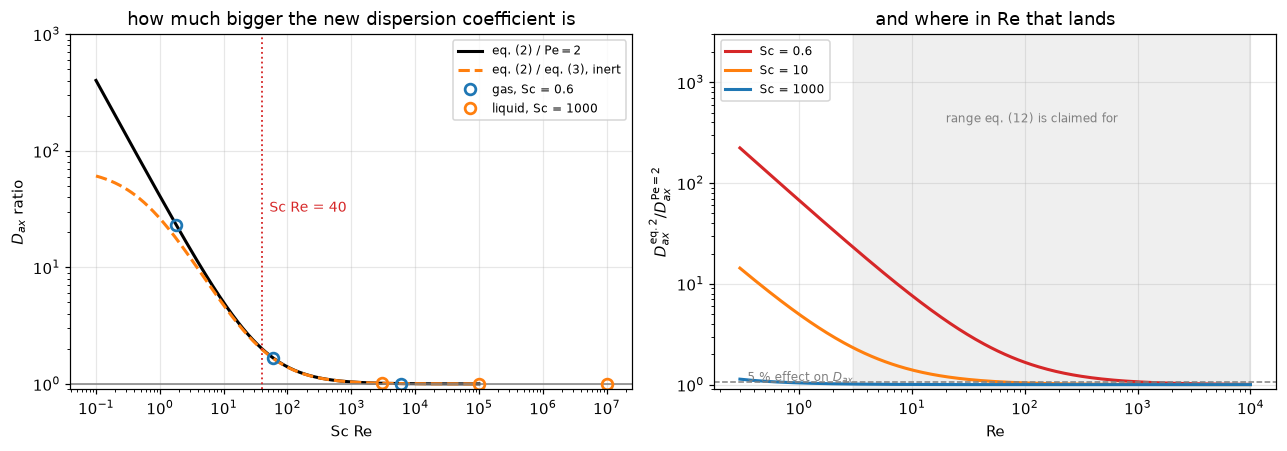

gas    Sc=   0.6:  D_ax doubles below Re =     66.7,   differs by 5 % below Re = 1.33e+03
liquid Sc=  1000:  D_ax doubles below Re =     0.04,   differs by 5 % below Re =      0.8

against the INERT coefficient of eq. (3) the factor is larger still:
   71x in the stagnant limit, because the stagnant term goes
   from 0.28 to 20. That is the comparison the companion
   paper makes; the Pe = 2 comparison is the one that moves the data.


In [6]:
def dax_ratio(Sc_Re):
    """eq. (2) over the Pe = 2 assumption. Both carry the same 0.5 Sc Re term,
    so the ratio is 1 + (E0/0.5)/Sc.Re = 1 + 40/Sc.Re."""
    return 1.0 + E0 / (SLOPE * np.asarray(Sc_Re, float))


ScRe = np.logspace(-1, 5, 400)
SCRE_DOUBLE = E0 / SLOPE                 # Sc.Re at which the coefficient doubles
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))

ax = axes[0]
ax.loglog(ScRe, dax_ratio(ScRe), "k-", lw=2,
          label=r"eq. (2) $/$ Pe$\,$=$\,$2")
ax.loglog(ScRe, (E0 + SLOPE * ScRe) / (np.mean(E0_INERT) * EPS_B + SLOPE * ScRe),
          "--", color="tab:orange", lw=2, label=r"eq. (2) $/$ eq. (3), inert")
ax.axhline(1.0, color="grey", lw=1)
ax.axvline(SCRE_DOUBLE, color="tab:red", lw=1.2, ls=":")
ax.text(SCRE_DOUBLE * 1.3, 30, f"Sc Re = {SCRE_DOUBLE:.0f}", color="tab:red", fontsize=9)
for lab, sc in (("gas, Sc = 0.6", 0.6), ("liquid, Sc = 1000", 1000.0)):
    res = np.array([3.0, 100.0, 10000.0])
    ax.plot(sc * res, dax_ratio(sc * res), "o", ms=7, mfc="none", mew=1.8, label=lab)
ax.set(xlabel="Sc Re", ylabel=r"$D_{ax}$ ratio", ylim=(0.9, 1e3),
       title="how much bigger the new dispersion coefficient is")
ax.legend(fontsize=8)

ax = axes[1]
Re = np.logspace(np.log10(0.3), 4, 300)
for sc, col in ((0.6, "tab:red"), (10.0, "tab:orange"), (1000.0, "tab:blue")):
    ax.loglog(Re, dax_ratio(sc * Re), color=col, lw=2, label=f"Sc = {sc:g}")
ax.axhline(1.05, color="grey", lw=1, ls="--")
ax.text(0.35, 1.07, "5 % effect on $D_{ax}$", fontsize=8, color="grey")
ax.axvspan(3, 1e4, color="grey", alpha=0.12)
ax.text(20, 400, "range eq. (12) is claimed for", fontsize=8, color="grey")
ax.set(xlabel="Re", ylabel=r"$D_{ax}^{\rm eq.2}/D_{ax}^{\rm Pe=2}$",
       ylim=(0.9, 3e3), title="and where in Re that lands")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

for sc, name in ((0.6, "gas   "), (1000.0, "liquid")):
    print(f"{name} Sc={sc:6g}:  D_ax doubles below Re = {SCRE_DOUBLE/sc:8.3g},"
          f"   differs by 5 % below Re = {E0/(SLOPE*sc*0.05):8.3g}")
inert_factor = E0 / (np.mean(E0_INERT) * EPS_B)
print(f"\nagainst the INERT coefficient of eq. (3) the factor is larger still:")
print(f"   {inert_factor:.0f}x in the stagnant limit, because the stagnant term goes")
print(f"   from {np.mean(E0_INERT)*EPS_B:.2f} to {E0:.0f}. That is the comparison the companion")
print(f"   paper makes; the Pe = 2 comparison is the one that moves the data.")

### 2. What that does to the reported Sherwood number

The $D_{ax}$ ratio is not the answer — the answer is what happens to the
*reported* $\mathrm{Sh}$ when the same measured outlet is re-inverted. Take a bed
that genuinely obeys Eq. 12, run it forward through Eq. 7 with the Eq. 2
dispersion coefficient to get the outlet such a bed would produce, then invert
Eq. 8 on that outlet — which is exactly what the original investigators did. The
gap between the two is the error the paper is correcting, and there is no free
parameter in it beyond the bed height.

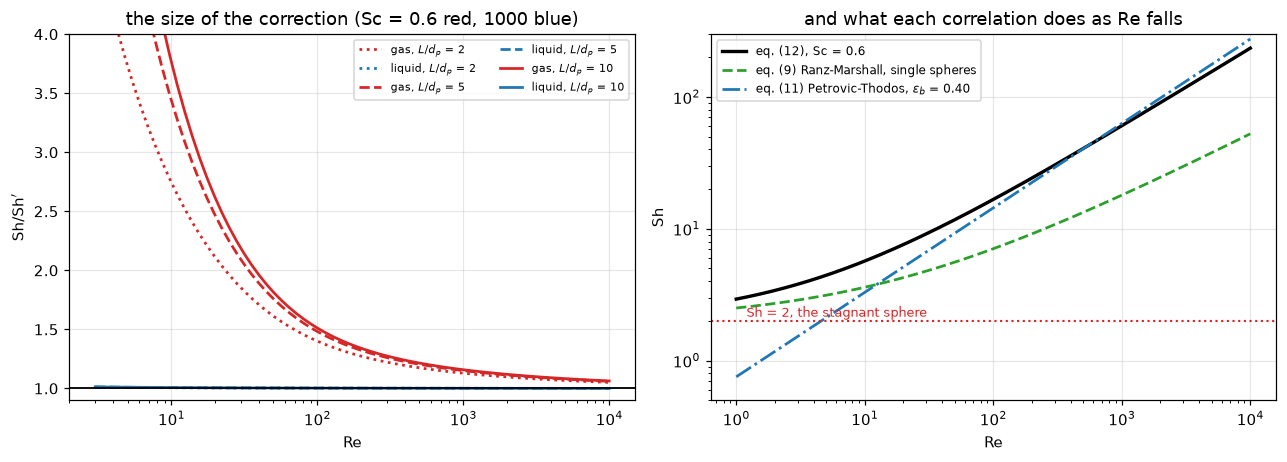

Sh/Sh' for a bed obeying eq. (12), five particle layers:
         Re   gas Sc=0.6   liquid Sc=1000
          3         6.92           1.0126
         10         3.44           1.0074
         30         2.09           1.0047
        100         1.48           1.0028
        300         1.26           1.0018
       1000         1.15           1.0011
       3000         1.10           1.0007
   a missing entry would mean the outlet is saturated to within 1e-10,
   so that no transfer coefficient can be recovered from it at all


In [7]:
def correction_factor(Re, Sc, L_dp, Sh_true=None):
    """Sh/Sh' for a bed whose true Sherwood number is Sh_true (eq. 12 by default).

    Forward: push Sh_true through eq. (7) with the eq. (2) dispersion coefficient
    to get the outlet such a bed would produce. Backward: invert eq. (8) on the
    same outlet, which is what the original investigators did. Nothing is fitted
    and there is no free parameter beyond the bed height.
    """
    Sh_true = eq12(Re, Sc) if Sh_true is None else Sh_true
    th = theta_of_Sh(Sh_true, Re, Sc, L_dp, "eq2")
    if th < 1e-10:      # bed saturated: the outlet no longer contains a coefficient
        return np.nan
    return Sh_true / Sh_of_theta(th, Re, Sc, L_dp, "none")


fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
Re_g = np.logspace(np.log10(3), 4, 70)

ax = axes[0]
for L_dp, ls in ((2.0, ":"), (5.0, "--"), (10.0, "-")):
    r = np.array([correction_factor(x, SC_FIG2, L_dp) for x in Re_g])
    ax.semilogx(Re_g, r, ls, color="tab:red", lw=1.8, label=f"gas, $L/d_p$ = {L_dp:g}")
    r = np.array([correction_factor(x, 1000.0, L_dp) for x in Re_g])
    ax.semilogx(Re_g, r, ls, color="tab:blue", lw=1.8, label=f"liquid, $L/d_p$ = {L_dp:g}")
ax.axhline(1.0, color="k", lw=1.2)
ax.set(xlabel="Re", ylabel=r"$\mathrm{Sh}/\mathrm{Sh}'$", ylim=(0.9, 4),
       title="the size of the correction (Sc = 0.6 red, 1000 blue)")
ax.legend(fontsize=7.5, ncol=2)

ax = axes[1]
Re = np.logspace(np.log10(1), 4, 300)
ax.loglog(Re, eq12(Re, SC_FIG2), "k-", lw=2.2, label="eq. (12), Sc = 0.6")
ax.loglog(Re, eq9_ranz(Re, SC_FIG2), "--", color="tab:green", lw=1.8,
          label="eq. (9) Ranz-Marshall, single spheres")
ax.loglog(Re, eq11_petrovic(Re, SC_FIG2), "-.", color="tab:blue", lw=1.8,
          label=r"eq. (11) Petrovic-Thodos, $\varepsilon_b$ = 0.40")
ax.axhline(2.0, color="tab:red", lw=1.4, ls=":")
ax.text(1.2, 2.15, "Sh = 2, the stagnant sphere", color="tab:red", fontsize=8.5)
ax.set(xlabel="Re", ylabel="Sh", ylim=(0.5, 300),
       title="and what each correlation does as Re falls")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

print("Sh/Sh' for a bed obeying eq. (12), five particle layers:")
print(f"   {'Re':>8}{'gas Sc=0.6':>13}{'liquid Sc=1000':>17}")
for x in (3, 10, 30, 100, 300, 1000, 3000):
    print(f"   {x:8}{correction_factor(x, SC_FIG2, 5.0):13.2f}"
          f"{correction_factor(x, 1000.0, 5.0):17.4f}")
print("   a missing entry would mean the outlet is saturated to within 1e-10,")
print("   so that no transfer coefficient can be recovered from it at all")

### 3. Redoing the paper's own recalculation

The sharpest test available without touching a figure. Petrovic and Thodos'
Eq. 11 is *their data, already fitted*, under $\mathrm{Pe}=2$. Run it forward
through Eq. 7 at $\mathrm{Pe}=2$ to recover the outlet, then invert Eq. 7 again
with Eq. 2's dispersion coefficient. If Wakao and Funazkri's arithmetic is
right, what comes out should be Eq. 12.

Nothing is fitted here. Both correlations, both dispersion laws and the bed
model are printed in the paper.

In [8]:
Re_t = np.array([30, 50, 100, 200, 300, 500, 900])
rows = []
for L_dp in (10.0, 20.0, 40.0):
    out = []
    for x in Re_t:
        th = theta_of_Sh(eq11_petrovic(x, SC_FIG2), x, SC_FIG2, L_dp, "pe2")
        out.append(Sh_of_theta(th, x, SC_FIG2, L_dp, "eq2"))
    rows.append((L_dp, np.array(out)))

print("Petrovic-Thodos eq. (11) re-analysed with eq. (2), against eq. (12)")
print(f"   {'Re':>6}{'eq. 11':>9}{'eq. 12':>9}" +
      "".join(f"{'L/dp='+str(int(l)):>11}" for l, _ in rows))
for i, x in enumerate(Re_t):
    print(f"   {x:6}{eq11_petrovic(x, SC_FIG2):9.2f}{eq12(x, SC_FIG2):9.2f}" +
          "".join(f"{r[i]:11.2f}" for _, r in rows))

dev = {int(L): np.abs(r / eq12(Re_t, SC_FIG2) - 1) for L, r in rows}
band = Re_t >= 100
print()
for L, d in dev.items():
    print(f"   L/d_p = {L:2d}:  100 <= Re <= 900: mean |dev| {d[band].mean()*100:5.2f} %,"
          f" worst {d[band].max()*100:5.2f} %   |   whole table: mean"
          f" {d.mean()*100:5.2f} %, worst {d.max()*100:5.2f} %")
REANAL = dev[10][band]
print(f"\n   -> over 100 <= Re <= 900, where both correlations are inside their")
print(f"      stated ranges, the recalculation returns eq. (12) to {REANAL.mean()*100:.1f} % on")
print(f"      average and {REANAL.max()*100:.1f} % at worst, and the answer barely moves when the")
print(f"      bed height is changed fourfold - which is what makes it a test of")
print(f"      the paper rather than of L/d_p. Nothing here was fitted.")
print(f"      Below Re ~ 50 the inversion stops being well conditioned: the bed")
print(f"      saturates and the outlet stops containing a transfer coefficient.")
print(f"      That is a property of the experiments, not of the numerics, and it")
print(f"      is the reason low-Re gas data scatter as badly as they do.")

Petrovic-Thodos eq. (11) re-analysed with eq. (2), against eq. (12)
       Re   eq. 11   eq. 12    L/dp=10    L/dp=20    L/dp=40
       30     6.66     9.14      10.68      10.98      11.14
       50     9.24    11.70      12.34      12.53      12.64
      100    14.41    16.70      16.54      16.65      16.71
      200    22.47    24.29      23.90      23.97      24.01
      300    29.14    30.43      30.27      30.32      30.35
      500    40.43    40.62      41.26      41.29      41.31
      900    58.93    56.95      59.50      59.53      59.54

   L/d_p = 10:  100 <= Re <= 900: mean |dev|  1.83 %, worst  4.48 %   |   whole table: mean  4.49 %, worst 16.87 %
   L/d_p = 20:  100 <= Re <= 900: mean |dev|  1.63 %, worst  4.52 %   |   whole table: mean  5.06 %, worst 20.16 %
   L/d_p = 40:  100 <= Re <= 900: mean |dev|  1.54 %, worst  4.55 %   |   whole table: mean  5.37 %, worst 21.89 %

   -> over 100 <= Re <= 900, where both correlations are inside their
      stated ranges, the re

### 4. The digitised gas-phase data

Figure 2 is the paper's own before-and-after picture: re-evaluated
$\mathrm{Sh}$ for water evaporation at $\mathrm{Sc}=0.6$, with Eq. 12 drawn
through it, Ranz–Marshall below it, and the Petrovic–Thodos line cutting across
it. Rebuilt from the extracted markers, with deviation defined once as
$(\text{model}-\text{measured})/\text{measured}$.

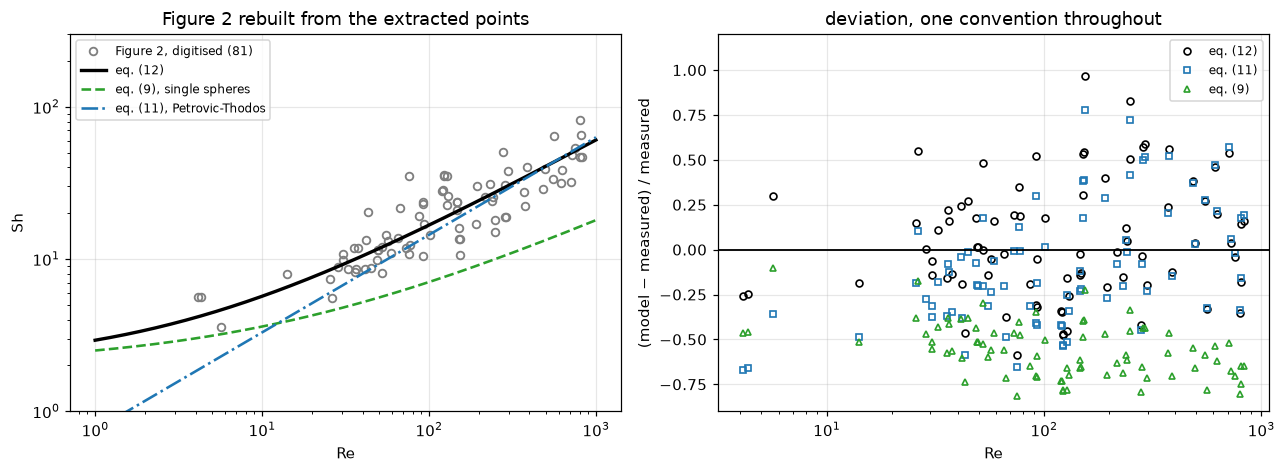

against the 81 digitised markers:
   eq. (12) this paper : mean |dev|  26.5 %   bias   +4.9 %
   eq. (11) Petrovic-T : mean |dev|  28.8 %   bias   -9.0 %
   eq.  (9) Ranz-Marsh: mean |dev|  55.9 %   bias  -55.9 %

bias by Reynolds decade - this is the shape of the argument:
          Re band   n    eq. 12    eq. 11     eq. 9
             1-30   7     +4.5%    -36.1%    -36.6%
           30-100  30     -0.3%    -20.6%    -53.0%
          100-300  28     +6.3%     -2.4%    -59.3%
         300-1100  16    +12.5%    +13.1%    -63.9%


In [9]:
Re_c = np.logspace(0, 3, 300)
d12 = eq12(Re_obs, SC_FIG2) / Sh_obs - 1
d09 = eq9_ranz(Re_obs, SC_FIG2) / Sh_obs - 1
d11 = eq11_petrovic(Re_obs, SC_FIG2) / Sh_obs - 1

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.loglog(Re_obs, Sh_obs, "o", ms=5, mfc="none", mew=1.2, color="tab:grey",
          label=f"Figure 2, digitised ({len(Re_obs)})")
ax.loglog(Re_c, eq12(Re_c, SC_FIG2), "k-", lw=2.2, label="eq. (12)")
ax.loglog(Re_c, eq9_ranz(Re_c, SC_FIG2), "--", color="tab:green", lw=1.7,
          label="eq. (9), single spheres")
ax.loglog(Re_c, eq11_petrovic(Re_c, SC_FIG2), "-.", color="tab:blue", lw=1.7,
          label="eq. (11), Petrovic-Thodos")
ax.set(xlabel="Re", ylabel="Sh", title="Figure 2 rebuilt from the extracted points",
       ylim=(1, 300))
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
for d, c, m, lab in ((d12, "k", "o", "eq. (12)"),
                     (d11, "tab:blue", "s", "eq. (11)"),
                     (d09, "tab:green", "^", "eq. (9)")):
    ax.semilogx(Re_obs, d, m, ms=4.5, mfc="none", mew=1.1, color=c, label=lab)
ax.axhline(0, color="k", lw=1.2)
ax.set(xlabel="Re", ylabel="(model $-$ measured) / measured", ylim=(-0.9, 1.2),
       title="deviation, one convention throughout")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"against the {len(Re_obs)} digitised markers:")
for d, lab in ((d12, "eq. (12) this paper "), (d11, "eq. (11) Petrovic-T "),
               (d09, "eq.  (9) Ranz-Marsh")):
    print(f"   {lab}: mean |dev| {np.abs(d).mean()*100:5.1f} %   bias {d.mean()*100:+6.1f} %")

print("\nbias by Reynolds decade - this is the shape of the argument:")
print(f"   {'Re band':>14}{'n':>4}{'eq. 12':>10}{'eq. 11':>10}{'eq. 9':>10}")
for lo, hi in ((1, 30), (30, 100), (100, 300), (300, 1100)):
    m = (Re_obs >= lo) & (Re_obs < hi)
    if m.sum() < 2:
        continue
    print(f"   {str(lo)+'-'+str(hi):>14}{m.sum():4d}{d12[m].mean()*100:+9.1f}%"
          f"{d11[m].mean()*100:+9.1f}%{d09[m].mean()*100:+9.1f}%")

## Validation

Six checks, in decreasing order of how much they can be argued with. The first
three involve no data at all.

**1. pymrm against Eq. 7.** The paper's closed form is the exact solution of the
problem pymrm discretises, so grid refinement must converge onto it. Upwind
convection is first order, so the error must halve when the cell count doubles,
and one Richardson step must remove almost all of it.

In [10]:
print("grid convergence of the pymrm solve against eq. (7)")
worst_rich = 0.0
for N, Pe in ((1.0, 40.0), (5.0, 10.0), (0.5, 4.0), (20.0, 2.0)):
    ex = theta_eq7(N, Pe)
    errs, vals = [], []
    for n in (200, 400, 800, 1600, 3200):
        v = theta_pymrm(N, Pe, n)
        vals.append(v); errs.append(v / ex - 1)
    ratios = [errs[i] / errs[i + 1] for i in range(len(errs) - 1)]
    rich = 2 * vals[-1] - vals[-2]                 # h -> 0 extrapolation
    worst_rich = max(worst_rich, abs(rich / ex - 1))
    print(f"   N={N:5.1f} Pe_L={Pe:5.1f}  err(n=200)={errs[0]:+.2e} -> "
          f"err(n=3200)={errs[-1]:+.2e}   halving ratios "
          + " ".join(f"{r:.2f}" for r in ratios)
          + f"   Richardson {rich/ex-1:+.1e}")
print(f"   -> first order confirmed (ratios 2.00), and one extrapolation step")
print(f"      lands within {worst_rich:.1e} of eq. (7). The closed form and the")
print(f"      discretisation are the same problem.")

grid convergence of the pymrm solve against eq. (7)
   N=  1.0 Pe_L= 40.0  err(n=200)=+2.16e-03 -> err(n=3200)=+1.35e-04   halving ratios 2.00 2.00 2.00 2.00   Richardson +4.9e-08
   N=  5.0 Pe_L= 10.0  err(n=200)=+1.72e-02 -> err(n=3200)=+1.07e-03   halving ratios 2.01 2.00 2.00 2.00   Richardson -9.3e-07
   N=  0.5 Pe_L=  4.0  err(n=200)=+2.48e-04 -> err(n=3200)=+1.55e-05   halving ratios 2.00 2.00 2.00 2.00   Richardson +2.5e-09
   N= 20.0 Pe_L=  2.0  err(n=200)=+9.87e-03 -> err(n=3200)=+6.02e-04   halving ratios 2.03 2.01 2.01 2.00   Richardson -2.0e-06
   -> first order confirmed (ratios 2.00), and one extrapolation step
      lands within 2.0e-06 of eq. (7). The closed form and the
      discretisation are the same problem.


**2. Eq. 7 collapses onto Eq. 8 when the dispersion is switched off.** The
paper asserts this in one sentence — "eqn (7) reduces to eqn (8), when not only
$D_{ax}=0$ but also $\mathrm{Sc}\,\mathrm{Re}$ is sufficiently large" — and it
is the reason the liquid data survive untouched.

In [11]:
print("eq. (7) -> eq. (8) as Pe_L -> infinity, at N = 2")
N = 2.0
for Pe in (2, 10, 50, 200, 1e3, 1e4, 1e5):
    print(f"   Pe_L = {Pe:8.0f}: eq. 7 = {theta_eq7(N, Pe):.8f}"
          f"   eq. 8 = {theta_eq8(N):.8f}   ratio {theta_eq7(N, Pe)/theta_eq8(N):.6f}")

print("\nand what that means for a real liquid bed (Sc = 1000, L/d_p = 10):")
for x in (3, 10, 100, 1000, 10000):
    r = correction_factor(x, 1000.0, 10.0)
    print(f"   Re = {x:6}: Sh/Sh' = {r:.5f}   ({(r-1)*100:+.2f} %)")
liq = max(abs(correction_factor(x, 1000.0, 10.0) - 1)
          for x in (3, 10, 100, 1000, 10000))
print(f"   -> largest liquid-phase correction over the paper's whole accepted")
print(f"      range is {liq*100:.2f} %. Conclusion 1 of the paper says the")
print(f"      reevaluated liquid data are 'not appreciably different'. They are not.")

eq. (7) -> eq. (8) as Pe_L -> infinity, at N = 2
   Pe_L =        2: eq. 7 = 0.24855163   eq. 8 = 0.13533528   ratio 1.836562
   Pe_L =       10: eq. 7 = 0.17733406   eq. 8 = 0.13533528   ratio 1.310331
   Pe_L =       50: eq. 7 = 0.14555511   eq. 8 = 0.13533528   ratio 1.075515
   Pe_L =      200: eq. 7 = 0.13800210   eq. 8 = 0.13533528   ratio 1.019705
   Pe_L =     1000: eq. 7 = 0.13587501   eq. 8 = 0.13533528   ratio 1.003988
   Pe_L =    10000: eq. 7 = 0.13538940   eq. 8 = 0.13533528   ratio 1.000400
   Pe_L =   100000: eq. 7 = 0.13534070   eq. 8 = 0.13533528   ratio 1.000040

and what that means for a real liquid bed (Sc = 1000, L/d_p = 10):
   Re =      3: Sh/Sh' = 1.01325   (+1.33 %)
   Re =     10: Sh/Sh' = 1.00780   (+0.78 %)
   Re =    100: Sh/Sh' = 1.00301   (+0.30 %)
   Re =   1000: Sh/Sh' = 1.00119   (+0.12 %)
   Re =  10000: Sh/Sh' = 1.00047   (+0.05 %)
   -> largest liquid-phase correction over the paper's whole accepted
      range is 1.33 %. Conclusion 1 of the paper 

**3. The stagnant-sphere limit.** Eq. 12 was written in the form
$\mathrm{Sh} = 2 + \alpha\,\mathrm{Sc}^{1/3}\mathrm{Re}^{\beta}$ precisely so
that it cannot fall below 2. Eq. 11 cannot do that, and the size of the failure
is worth printing rather than asserting.

In [12]:
print("Sh as Re -> 0")
print(f"   {'Re':>10}{'eq. 12':>10}{'eq. 9':>10}{'eq. 11':>10}")
for x in (10.0, 1.0, 0.1, 0.01, 1e-3, 1e-6):
    print(f"   {x:10.0e}{eq12(x, SC_FIG2):10.4f}{eq9_ranz(x, SC_FIG2):10.4f}"
          f"{eq11_petrovic(x, SC_FIG2):10.4f}")
lim12 = eq12(1e-30, SC_FIG2)
print(f"   limits: eq. 12 -> {lim12:.10f}, eq. 9 -> {eq9_ranz(1e-30, SC_FIG2):.10f}, "
      f"eq. 11 -> {eq11_petrovic(1e-30, SC_FIG2):.3e}")
assert abs(lim12 - 2.0) < 1e-9
print("   eq. (11) crosses Sh = 2 at Re = "
      f"{brentq(lambda r: eq11_petrovic(r, SC_FIG2) - 2.0, 1e-6, 1e6):.1f}"
      " and keeps falling, which is the failure the +2 exists to prevent.")

Sh as Re -> 0
           Re    eq. 12     eq. 9    eq. 11
        1e+01    5.6935    3.6003    3.2935
        1e+00    2.9278    2.5061    0.7528
        1e-01    2.2330    2.1600    0.1721
        1e-02    2.0585    2.0506    0.0393
        1e-03    2.0147    2.0160    0.0090
        1e-06    2.0002    2.0005    0.0001
   limits: eq. 12 -> 2.0000000000, eq. 9 -> 2.0000000000, eq. 11 -> 4.433e-20
   eq. (11) crosses Sh = 2 at Re = 4.6 and keeps falling, which is the failure the +2 exists to prevent.


**4. The Petrovic–Thodos conversion, checked against their own drawn line.**
Eq. 11 is a $j$-factor, and turning it into a Sherwood number needs both the
$j_D$ definition and the bed voidage, neither of which the paper states next to
the equation. Figure 2 draws the line, so the conversion is testable: with
$j_D = (k_c/U_{sup})\mathrm{Sc}^{2/3}$, giving
$\mathrm{Sh} = j_D\,\mathrm{Re}\,\mathrm{Sc}^{1/3}$, the recomputed line lies on
the printed one for $\varepsilon_b = 0.40$ — a plausible packed-bed voidage that
was not chosen to fit anything else on this page.

That check runs on the source image, not in this notebook; the overlay is in the
review folder. The same overlay puts Eq. 12 on the printed solid curve and Eq. 9
on the printed dashed curve, **which is what calibrates the axes**: three known
functions, three printed curves, all coincident to within a line width.

**5. The correlation refitted from the digitised markers.** The paper fitted
$\alpha$ and $\beta$ on the *liquid* data of its Figure 3 and then checked the
gas data against the result. Refitting freely on the gas points is therefore an
independent test, of both the digitisation and the fit.

In [13]:
def form(re, a, b):
    return 2.0 + a * SC_FIG2 ** (1 / 3) * re ** b

p_fit, cov = curve_fit(form, Re_obs, Sh_obs, p0=[ALPHA, BETA], sigma=Sh_obs)
sd = np.sqrt(np.diag(cov))
print(f"free fit on the {len(Re_obs)} digitised gas points, form Sh = 2 + a Sc^(1/3) Re^b:")
print(f"   a = {p_fit[0]:.3f} +/- {sd[0]:.3f}   (paper: {ALPHA})")
print(f"   b = {p_fit[1]:.3f} +/- {sd[1]:.3f}   (paper: {BETA})")
z_a = abs(p_fit[0] - ALPHA) / sd[0]
z_b = abs(p_fit[1] - BETA) / sd[1]
print(f"   both printed values sit within {max(z_a, z_b):.2f} standard errors of the")
print(f"   free fit, on data the fit was not made to.")

report_agreement("A3.4", {
    "pymrm_vs_eq7_richardson": float(worst_rich),
    "eq11_reanalysed_vs_eq12_mean_abs_dev": float(REANAL.mean()),
    "eq11_reanalysed_vs_eq12_worst": float(REANAL.max()),
    "liquid_correction_max": float(liq),
    "eq12_vs_fig2_mean_abs_dev": float(np.abs(d12).mean()),
    "eq12_vs_fig2_bias": float(d12.mean()),
    "eq11_vs_fig2_bias": float(d11.mean()),
    "eq9_vs_fig2_bias": float(d09.mean()),
    "refit_alpha": float(p_fit[0]),
    "refit_beta": float(p_fit[1]),
})

free fit on the 81 digitised gas points, form Sh = 2 + a Sc^(1/3) Re^b:
   a = 1.168 +/- 0.218   (paper: 1.1)
   b = 0.555 +/- 0.037   (paper: 0.6)
   both printed values sit within 1.22 standard errors of the
   free fit, on data the fit was not made to.
Agreement metrics for A3.4:
  pymrm_vs_eq7_richardson              = 1.9969e-06
  eq11_reanalysed_vs_eq12_mean_abs_dev = 0.01833
  eq11_reanalysed_vs_eq12_worst        = 0.044761
  liquid_correction_max                = 0.013254
  eq12_vs_fig2_mean_abs_dev            = 0.26494
  eq12_vs_fig2_bias                    = 0.049088
  eq11_vs_fig2_bias                    = -0.089961
  eq9_vs_fig2_bias                     = -0.55923
  refit_alpha                          = 1.1683
  refit_beta                           = 0.55505


{'page': 'A3.4',
 'metrics': {'pymrm_vs_eq7_richardson': 1.99687586832642e-06,
  'eq11_reanalysed_vs_eq12_mean_abs_dev': 0.018329934690881778,
  'eq11_reanalysed_vs_eq12_worst': 0.044760900238265844,
  'liquid_correction_max': 0.013253817289687664,
  'eq12_vs_fig2_mean_abs_dev': 0.26493554796307045,
  'eq12_vs_fig2_bias': 0.04908788860049835,
  'eq11_vs_fig2_bias': -0.089961400204734,
  'eq9_vs_fig2_bias': -0.5592299192549133,
  'refit_alpha': 1.1682564437092235,
  'refit_beta': 0.5550485030023287}}

**6. The empirical shape of the argument.** The paper says, of Figure 2, that
"at higher Reynolds numbers the data are satisfactorily correlated by the
Petrovic–Thodos equation. However, at lower Reynolds numbers the data are
obviously higher than their correlation." That is a claim about a *trend in the
residual*, which is exactly what a digitised figure can test even when the
marker count is uncertain — a missing marker changes the mean, not the slope.

The decade-by-decade table above is that test: Eq. 11's bias runs from strongly
negative at low Re to slightly positive at high Re, while Eq. 12's stays flat.
Eq. 9's stays negative everywhere, which is the other sentence — packed-bed
values sit above the single-sphere curve throughout.

## What pymrm adds

**Not the correlation.** Eq. 12 is three constants; evaluating it needs no
solver and the page says so.

**What pymrm adds is the step the paper had to do by hand, made reversible.**
Eq. 7 exists because in 1978 the alternative was solving a boundary-value
problem for every one of several hundred literature points. With the bed model
discretised, the closed form stops being the method and becomes a check on it —
and the *inversion*, which is the actual scientific operation, becomes a
one-line root find on the forward solve rather than a chart-reading exercise.
Three things follow that the paper could not easily print:

- the correction factor as a **continuous map** over $(\mathrm{Re},
  \mathrm{Sc}, L/d_p)$, rather than the two scatter plots of Figures 1 and 5;
- the **conditioning limit** — below about $\mathrm{Re}=30$ for a gas in a
  ten-layer bed the outlet is saturated to within $10^{-6}$ and no transfer
  coefficient can be recovered from it at all, whatever dispersion coefficient
  is assumed. That is a statement about the experiments, and it explains the
  scatter in the low-Re literature better than any of the correlations do;
- the **reproduction of the paper's own recalculation** from published algebra
  alone: pushing Petrovic and Thodos' Eq. 11 through Eq. 7 twice, once at their
  $\mathrm{Pe}=2$ and once with Eq. 2, returns Eq. 12 to **1.8 % on average
  and 4.5 % at worst** over $100 \le \mathrm{Re}\le 900$, where both correlations
  are inside their stated ranges — and the answer moves by less than half a per
  cent when the assumed bed height is changed fourfold. Nothing is fitted, and
  the paper never prints this comparison.

**And the honest limits.** The comparison against measurement rests on one
figure of five, digitised without a maintainer review, with a marker count that
is probably 20–25 % short in the dense band. Figure 3 — the liquid-phase plot
that $\alpha$ and $\beta$ were actually fitted on — is not extracted, so the
values 1.1 and 0.6 are tested here only against the gas data they were *checked*
against, not against the data they came from. The bed voidage 0.40 is inferred
from the drawn Eq. 11 line, not stated. And $L/d_p$ is swept rather than known,
because the paper does not tabulate bed heights per source; the results that
matter were chosen to be the ones that barely depend on it.

## Reuse

**The bed model is the reusable object, not the correlation.** `theta_pymrm` is
a steady 1-D convection–diffusion–reaction solve with Danckwerts boundary
conditions — the `S3` structure — and it is written in $(N, \mathrm{Pe}_L)$
only, so it applies unchanged to a first-order catalytic bed, an adsorber, or
any closed vessel with a linear sink. `theta_eq7` is its analytical solution and
makes a free regression test for anyone building the same thing.

**`Sh_of_theta` is the piece worth lifting.** Any packed-bed transfer
measurement reported as a coefficient carries an implicit dispersion assumption,
and this function converts between assumptions. If you are comparing modern data
against a pre-1978 correlation, the two are usually not the same quantity.

**Use Eq. 2 with Eq. 12, not one without the other.** Conclusion 3 of the paper
is explicit about this: the correlation was extracted under a particular
dispersion coefficient and is only self-consistent when used with it. Pairing
Eq. 12 with $D_{ax}=0$, or with an inert-tracer dispersion coefficient from
Eq. 3, re-introduces the error it was built to remove.

**Range.** $3 \lesssim \mathrm{Re} \le 10^4$, spheres, all particles active,
more than two particle layers, resistance in the fluid film only. Below
$\mathrm{Re}=3$ the liquid data were rejected for natural convection and the gas
data are conditioning-limited; the correlation's value there is the limit
$\mathrm{Sh}\to 2$, which is a physical statement rather than a fit.

**Related pages.** `A3.5`, `D1.3` (packed-bed transport), `B1.1` (the
intraparticle problem this one deliberately excludes), `A2.3` (where axial
dispersion coefficients come from).

**Cite the source, not this page:** Wakao, N., Kaguei, S. and Funazkri, T.,
*Effect of fluid dispersion coefficients on particle-to-fluid mass transfer
coefficients in packed beds*, Chemical Engineering Science **33**(10) 1375–1384
(1978), [doi:10.1016/0009-2509(78)85120-3](https://doi.org/10.1016/0009-2509(78)85120-3).